# Understanding Population Data (Exposure)

This tutorial helps you understand population data using the Global Human Settlement (GHS) datasets. You'll explore and compare two different datasets to understand their characteristics and differences.

We'll work with:
- **GHS-POP**: Historical and projected population (1975-2030)
- **GHS-WUP**: Urban population projections (1975-2100)

**Prerequisites**: We'll use preprocessed data for the region "Central Greece" (NUTS2 region "EL64")). If you change the region, please download and process the data population data for your region using the [Population GHS how-to guide](../how-to-guides/population_ghs.ipynb).

**What you'll learn**:
- Load and visualize population timeseries from CSV files
- Explore spatial population distributions from raster data
- Compare different population datasets
- Understand temporal and spatial patterns in population dynamics

## Setup

### User settings

In [38]:
admin_id = "EL64"  # Central Greece
workdir = "/home/nejk/code/drought_exposure"

### Load libraries

In [39]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd
import regionmask
from pathlib import Path
import rioxarray as rxr
import os
import re

# Set working directory
os.chdir(workdir)
print(f"Working directory: {os.getcwd()}")

# Set up data directories
data_dir = Path("./data")
ghs_pop_dir = data_dir / "population" / "GHS_POP"
ghs_wup_dir = data_dir / "population" / "GHS_WUP_POP"
output_dir = data_dir / admin_id / "ghs_population"

print(f"Data directories:")
print(f"  GHS-POP: {ghs_pop_dir}")
print(f"  GHS-WUP: {ghs_wup_dir}")
print(f"  Output: {output_dir}")

Working directory: /etc/ecmwf/nfs/dh2_home_a/nejk/code/drought_exposure
Data directories:
  GHS-POP: data/population/GHS_POP
  GHS-WUP: data/population/GHS_WUP_POP
  Output: data/EL64/ghs_population


### Load region shapefile

In [40]:
# Read NUTS shapefiles
regions_dir = data_dir / 'regions'
nuts_shp = regions_dir / 'NUTS_RG_20M_2024_4326' / 'NUTS_RG_20M_2024_4326.shp'
nuts_gdf = gpd.read_file(nuts_shp)

# Select the region of interest
sel_gdf = nuts_gdf[nuts_gdf['NUTS_ID'] == admin_id]
print(f"Region: {sel_gdf['NUTS_NAME'].values[0]} ({admin_id})")
print(f"Country: {sel_gdf['CNTR_CODE'].values[0]}")
lon_min, lat_min, lon_max, lat_max = sel_gdf.geometry.total_bounds

# Create a regionmask from the admin region geometry
admin_mask = regionmask.from_geopandas(sel_gdf, names='NUTS_ID')

Region: Στερεά Ελλάδα (EL64)
Country: EL


## Load Population Timeseries

First, let's load the processed CSV files created by the [population_ghs how-to guide](../how-to-guides/population_ghs.ipynb).

In [41]:
# Load CSV files
csv_ghs_pop = output_dir / f"population_ghs_pop_{admin_id}.csv"
csv_ghs_wup = output_dir / f"population_ghs_wup_{admin_id}.csv"

# Read the data
df_ghs_pop = pd.read_csv(csv_ghs_pop)
df_ghs_wup = pd.read_csv(csv_ghs_wup)

print("GHS-POP data:")
print(f"  Years: {df_ghs_pop['year'].min():.0f} - {df_ghs_pop['year'].max():.0f}")
print(f"  Records: {len(df_ghs_pop)}")
print(f"\nGHS-WUP data:")
print(f"  Years: {df_ghs_wup['year'].min():.0f} - {df_ghs_wup['year'].max():.0f}")
print(f"  Records: {len(df_ghs_wup)}")

# Display first few rows
print(f"\nGHS-POP sample:")
print(df_ghs_pop.head())
print(f"\nGHS-WUP sample:")
print(df_ghs_wup.head())

GHS-POP data:
  Years: 1975 - 2030
  Records: 12

GHS-WUP data:
  Years: 1975 - 2100
  Records: 26

GHS-POP sample:
   year     population
0  1975  416420.375064
1  1980  428631.335356
2  1985  462089.214682
3  1990  493136.923161
4  1995  518886.744711

GHS-WUP sample:
   year     population
0  1975  425902.285106
1  1980  444017.973223
2  1985  470750.898576
3  1990  490412.746349
4  1995  508224.276600


## Compare Population Timeseries

Let's visualize and compare the two datasets to understand their differences.

### Visualize both datasets

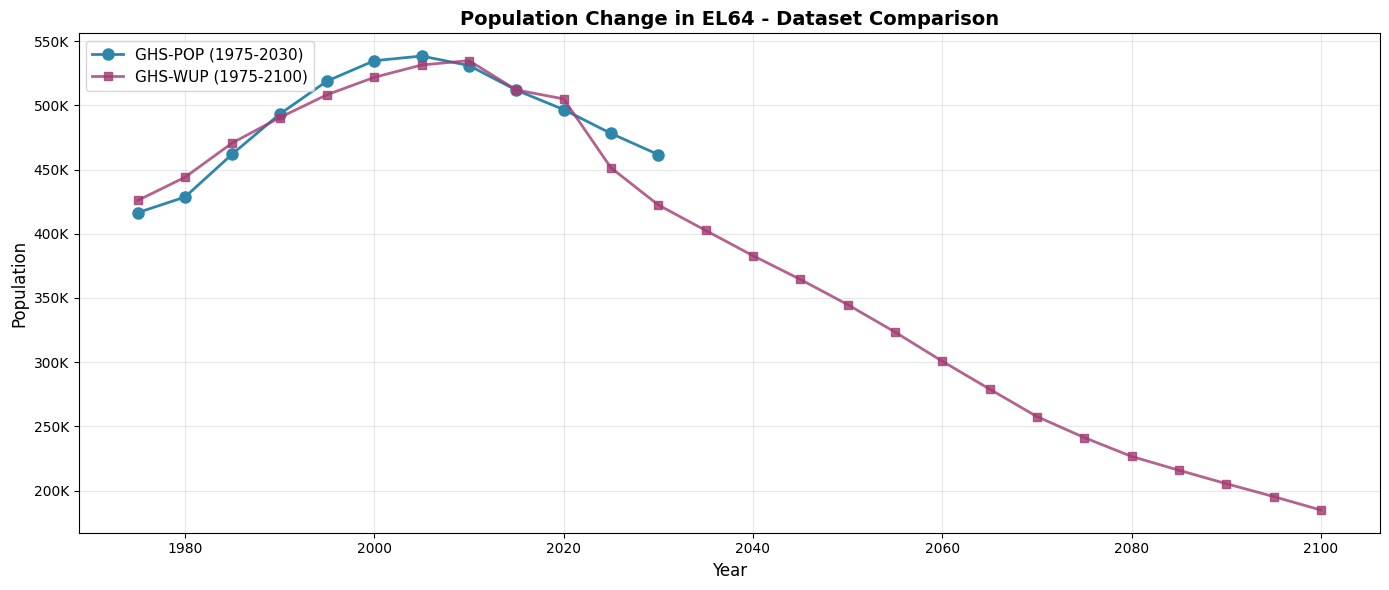

In [42]:
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(df_ghs_pop['year'], df_ghs_pop['population'], 
        marker='o', linewidth=2, markersize=8, label='GHS-POP (1975-2030)', color='#2E86AB')
ax.plot(df_ghs_wup['year'], df_ghs_wup['population'], 
        marker='s', linewidth=2, markersize=6, label='GHS-WUP (1975-2100)', color='#A23B72', alpha=0.8)

ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Population', fontsize=12)
ax.set_title(f'Population Change in {admin_id} - Dataset Comparison', fontsize=14, fontweight='bold')
ax.legend(fontsize=11, loc='upper left')
ax.grid(True, alpha=0.3)

# Format y-axis
from matplotlib.ticker import FuncFormatter
def millions(x, pos):
    return f'{x/1e6:.1f}M' if x >= 1e6 else f'{x/1e3:.0f}K'
ax.yaxis.set_major_formatter(FuncFormatter(millions))

plt.tight_layout()
plt.show()

### Quantify differences

For overlapping years (1975-2030), let's calculate the differences between the two datasets.

In [43]:
# Merge datasets on year for overlapping period
df_comparison = df_ghs_pop.merge(df_ghs_wup, on='year', suffixes=('_pop', '_wup'))

# Calculate differences
df_comparison['difference'] = df_comparison['population_wup'] - df_comparison['population_pop']
df_comparison['percent_diff'] = (df_comparison['difference'] / df_comparison['population_pop']) * 100

print("Dataset Comparison (1975-2030):")
print("="*80)
print(f"{'Year':<8} {'GHS-POP':>15} {'GHS-WUP':>15} {'Difference':>15} {'Diff %':>10}")
print("-"*80)

for _, row in df_comparison.iterrows():
    print(f"{row['year']:<8.0f} {row['population_pop']:>15,.0f} {row['population_wup']:>15,.0f} "
          f"{row['difference']:>15,.0f} {row['percent_diff']:>9.2f}%")

print("\nSummary Statistics:")
print(f"  Mean absolute difference: {df_comparison['difference'].abs().mean():,.0f} people")
print(f"  Mean percentage difference: {df_comparison['percent_diff'].abs().mean():.2f}%")
print(f"  Max difference: {df_comparison['difference'].abs().max():,.0f} in {df_comparison.loc[df_comparison['difference'].abs().idxmax(), 'year']:.0f}")

Dataset Comparison (1975-2030):
Year             GHS-POP         GHS-WUP      Difference     Diff %
--------------------------------------------------------------------------------
1975             416,420         425,902           9,482      2.28%
1980             428,631         444,018          15,387      3.59%
1985             462,089         470,751           8,662      1.87%
1990             493,137         490,413          -2,724     -0.55%
1995             518,887         508,224         -10,662     -2.05%
2000             534,728         521,798         -12,930     -2.42%
2005             538,363         531,397          -6,966     -1.29%
2010             530,982         534,820           3,837      0.72%
2015             511,821         511,960             139      0.03%
2020             496,688         505,003           8,314      1.67%
2025             478,108         451,386         -26,722     -5.59%
2030             461,641         422,460         -39,181     -8.49%

Su

## Explore Spatial Population Distribution

Now let's load and visualize the actual spatial raster data to understand population distribution patterns.

### Load GHS-POP raster data

### Interactive map of present-day population

First, let's create an interactive map of the current population distribution that you can zoom and explore.

In [44]:
# Load 2020 data for interactive map
!pip install folium
import folium
from folium import plugins

# Load GHS-POP files
ghs_pop_files = sorted(list(ghs_pop_dir.glob("*/GHS_POP_E*_GLOBE_R2023A_4326_30ss_V1_0.tif")))

# Load GHS-POP 2020
present_year = 2020
ghs_pop_2020_file = [f for f in ghs_pop_files if f"E{present_year}" in f.name]

if ghs_pop_2020_file:
    tif_file = ghs_pop_2020_file[0]
    ds_2020 = rxr.open_rasterio(tif_file)
    # Clip to region
    ds_2020_clipped = ds_2020.sel(x=slice(lon_min, lon_max), y=slice(lat_max, lat_min))
    ds_2020_clipped = ds_2020_clipped.where(ds_2020_clipped >= 0)
    pop_2020 = ds_2020_clipped.squeeze("band", drop=True)
    
    # Apply mask
    mask_2020 = admin_mask.mask(pop_2020.x, pop_2020.y)
    pop_2020_masked = pop_2020.where(~np.isnan(mask_2020.values))
    
    print(f"Loaded GHS-POP {present_year} for interactive map")
    print(f"Data shape: {pop_2020_masked.shape}")
    print(f"Value range: {float(pop_2020_masked.min()):.2f} - {float(pop_2020_masked.max()):.2f}")
else:
    print(f"Could not find GHS-POP {present_year} file")

Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 25.1.1 -> 26.0
[notice] To update, run: pip install --upgrade pip
Loaded GHS-POP 2020 for interactive map
Data shape: (154, 393)
Value range: 0.00 - 7606.67


In [45]:
# Create interactive folium map
# Calculate center of region
center_lat = (lat_min + lat_max) / 2
center_lon = (lon_min + lon_max) / 2

# Create base map with a nice satellite/terrain basemap
m = folium.Map(
    location=[center_lat, center_lon],
    zoom_start=9,
    tiles=None  # We'll add custom tiles
)

# Add multiple basemap options
folium.TileLayer('OpenStreetMap', name='OpenStreetMap').add_to(m)
folium.TileLayer(
    tiles='https://server.arcgisonline.com/ArcGIS/rest/services/World_Imagery/MapServer/tile/{z}/{y}/{x}',
    attr='Esri World Imagery',
    name='Satellite',
    overlay=False,
    control=True
).add_to(m)
folium.TileLayer(
    tiles='https://server.arcgisonline.com/ArcGIS/rest/services/World_Topo_Map/MapServer/tile/{z}/{y}/{x}',
    attr='Esri World Topo',
    name='Topographic',
    overlay=False,
    control=True
).add_to(m)

# Add region boundary
folium.GeoJson(
    sel_gdf.geometry,
    name=f'Region {admin_id}',
    style_function=lambda x: {
        'fillColor': 'none',
        'color': 'red',
        'weight': 3,
        'fillOpacity': 0
    }
).add_to(m)

# Add population data as a heatmap overlay
# Convert to numpy array and get coordinates
pop_array = pop_2020_masked.values
y_coords = pop_2020_masked.y.values
x_coords = pop_2020_masked.x.values

# Create heat map data points (sample for performance)
heat_data = []
step = max(1, len(y_coords) // 100)  # Sample every nth point for performance

for i in range(0, len(y_coords), step):
    for j in range(0, len(x_coords), step):
        val = pop_array[i, j]
        if not np.isnan(val) and val > 0:
            heat_data.append([y_coords[i], x_coords[j], float(val)])

# Add heatmap
plugins.HeatMap(
    heat_data,
    name='Population Heatmap',
    min_opacity=0.3,
    max_zoom=13,
    radius=15,
    blur=20,
    gradient={0.4: 'yellow', 0.6: 'orange', 0.8: 'red', 1.0: 'darkred'}
).add_to(m)

# Add layer control
folium.LayerControl().add_to(m)

# Add title
title_html = f'''
<div style="position: fixed; 
     top: 10px; left: 50px; width: 400px; height: 60px; 
     background-color: white; border:2px solid grey; z-index:9999; 
     font-size:16px; padding: 10px; box-shadow: 2px 2px 6px rgba(0,0,0,0.3);">
     <b>Population Distribution {admin_id} ({present_year})</b><br>
     <i>Toggle layers and zoom to explore</i>
</div>
'''
m.get_root().html.add_child(folium.Element(title_html))

# Display map
m

In [46]:
# Load GHS-POP files for selected years
ghs_pop_files = sorted(list(ghs_pop_dir.glob("*/GHS_POP_E*_GLOBE_R2023A_4326_30ss_V1_0.tif")))
print(f"Found {len(ghs_pop_files)} GHS-POP files")

# Load selected years: 1990, 2000, 2010, 2020, 2030
selected_years_pop = [1990, 2000, 2010, 2020, 2030]
pop_data_dict = {}

for year in selected_years_pop:
    matching_files = [f for f in ghs_pop_files if f"E{year}" in f.name]
    if matching_files:
        tif_file = matching_files[0]
        ds = rxr.open_rasterio(tif_file)
        # Clip to region
        ds_clipped = ds.sel(x=slice(lon_min, lon_max), y=slice(lat_max, lat_min))
        ds_clipped = ds_clipped.where(ds_clipped >= 0)  # Remove fill values
        pop_data_dict[year] = ds_clipped.squeeze("band", drop=True)
        print(f"  Loaded {year}: shape {ds_clipped.shape}")

print(f"\nLoaded {len(pop_data_dict)} years of GHS-POP data")

Found 12 GHS-POP files
  Loaded 1990: shape (1, 154, 393)
  Loaded 2000: shape (1, 154, 393)
  Loaded 2010: shape (1, 154, 393)
  Loaded 2020: shape (1, 154, 393)
  Loaded 2030: shape (1, 154, 393)

Loaded 5 years of GHS-POP data


### Load GHS-WUP raster data

In [47]:
# Load GHS-WUP files for the same years
ghs_wup_files = sorted(list(ghs_wup_dir.glob("*/GHS_WUP_POP_E*_GLOBE_R2025A_4326_30ss_V1_0.tif")))
print(f"Found {len(ghs_wup_files)} GHS-WUP files")

wup_data_dict = {}

for year in selected_years_pop:
    matching_files = [f for f in ghs_wup_files if f"E{year}" in f.name]
    if matching_files:
        tif_file = matching_files[0]
        ds = rxr.open_rasterio(tif_file)
        # Clip to region
        ds_clipped = ds.sel(x=slice(lon_min, lon_max), y=slice(lat_max, lat_min))
        ds_clipped = ds_clipped.where(ds_clipped >= 0)  # Remove fill values
        wup_data_dict[year] = ds_clipped.squeeze("band", drop=True)
        print(f"  Loaded {year}: shape {ds_clipped.shape}")

print(f"\nLoaded {len(wup_data_dict)} years of GHS-WUP data")

Found 26 GHS-WUP files
  Loaded 1990: shape (1, 154, 393)
  Loaded 2000: shape (1, 154, 393)
  Loaded 2010: shape (1, 154, 393)
  Loaded 2020: shape (1, 154, 393)
  Loaded 2030: shape (1, 154, 393)

Loaded 5 years of GHS-WUP data


### Visualize spatial distribution: GHS-POP

Let's visualize how population is distributed spatially across the region for different time periods.

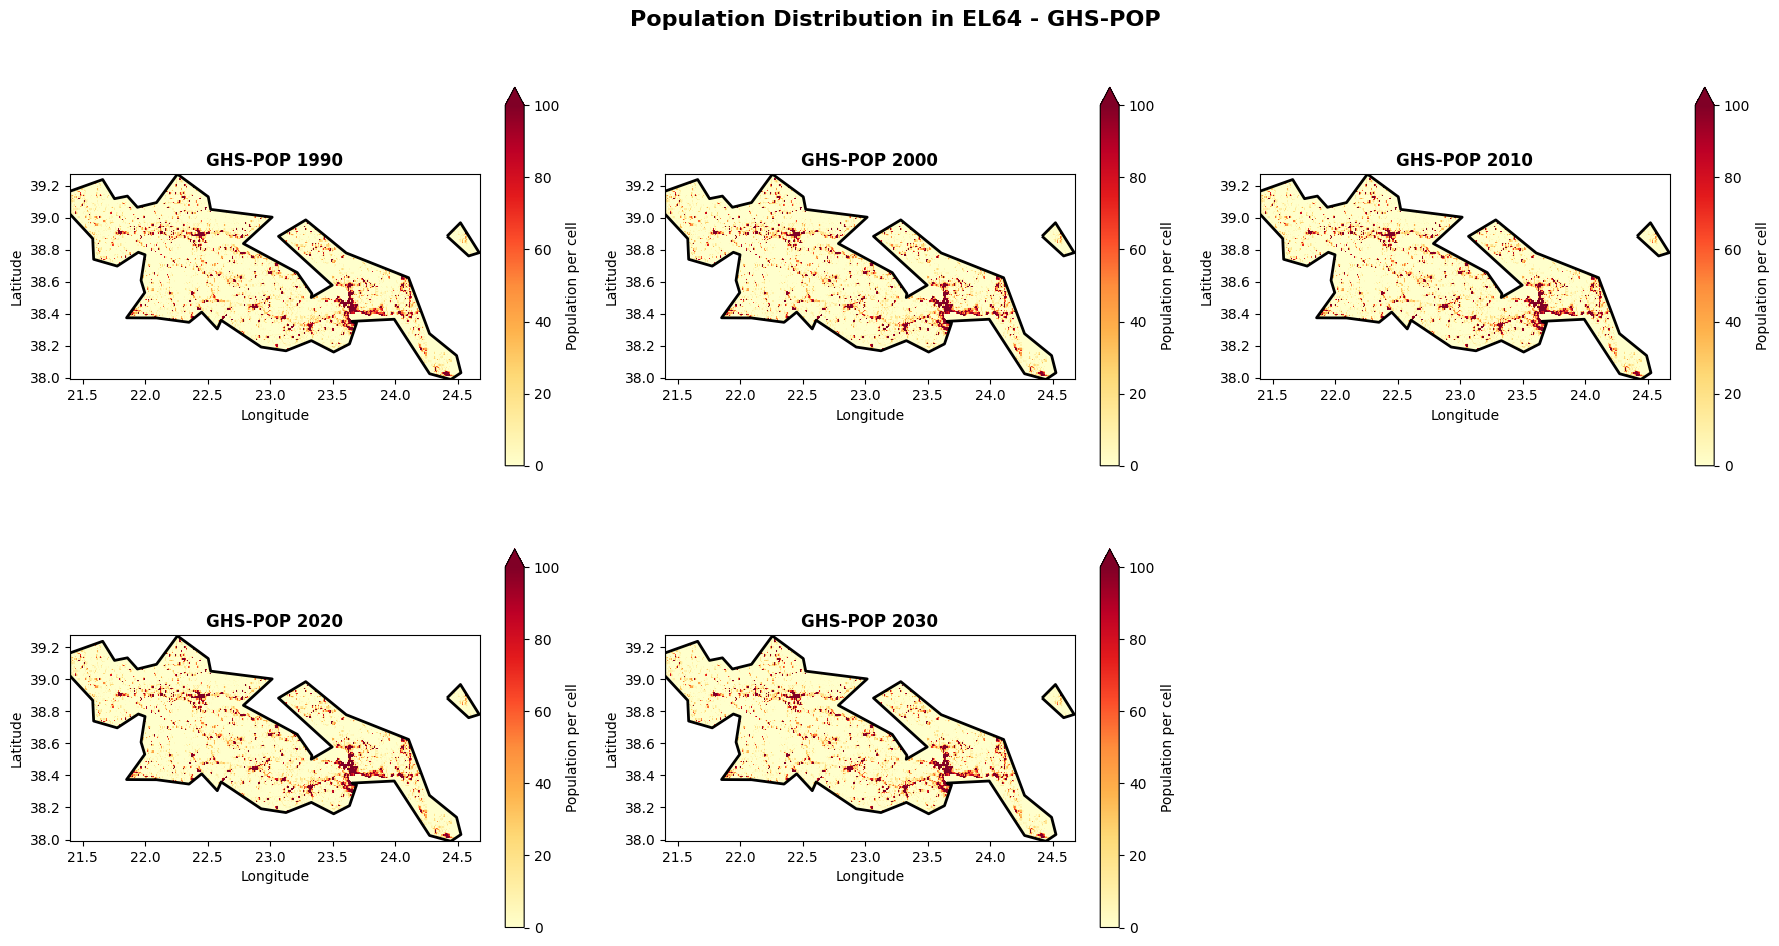

In [48]:
# Create region mask (use first available year to create mask)
first_year = selected_years_pop[0]
pop_admin_mask_raw = admin_mask.mask(pop_data_dict[first_year].x, pop_data_dict[first_year].y)

# Plot GHS-POP for selected years
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, year in enumerate(selected_years_pop):
    if year in pop_data_dict:
        # Create mask for this specific year's coordinates
        mask_raw = admin_mask.mask(pop_data_dict[year].x, pop_data_dict[year].y)
        pop_mask = xr.DataArray(
            (~np.isnan(mask_raw.values)).astype(float),
            coords={'y': pop_data_dict[year].y, 'x': pop_data_dict[year].x},
            dims=['y', 'x']
        )
        
        masked_pop = pop_data_dict[year].where(pop_mask == 1)
        
        im = masked_pop.plot(
            ax=axes[idx],
            cmap='YlOrRd',
            add_colorbar=True,
            cbar_kwargs={'label': 'Population per cell', 'shrink': 0.8},
            vmin=0,
            vmax=100
        )
        
        axes[idx].set_title(f'GHS-POP {year}', fontsize=12, fontweight='bold')
        axes[idx].set_xlabel('Longitude')
        axes[idx].set_ylabel('Latitude')
        sel_gdf.boundary.plot(ax=axes[idx], color='black', linewidth=2)

# Remove the last subplot if odd number
if len(selected_years_pop) < 6:
    fig.delaxes(axes[5])

plt.suptitle(f'Population Distribution in {admin_id} - GHS-POP', fontsize=16, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

### Visualize spatial distribution: GHS-WUP

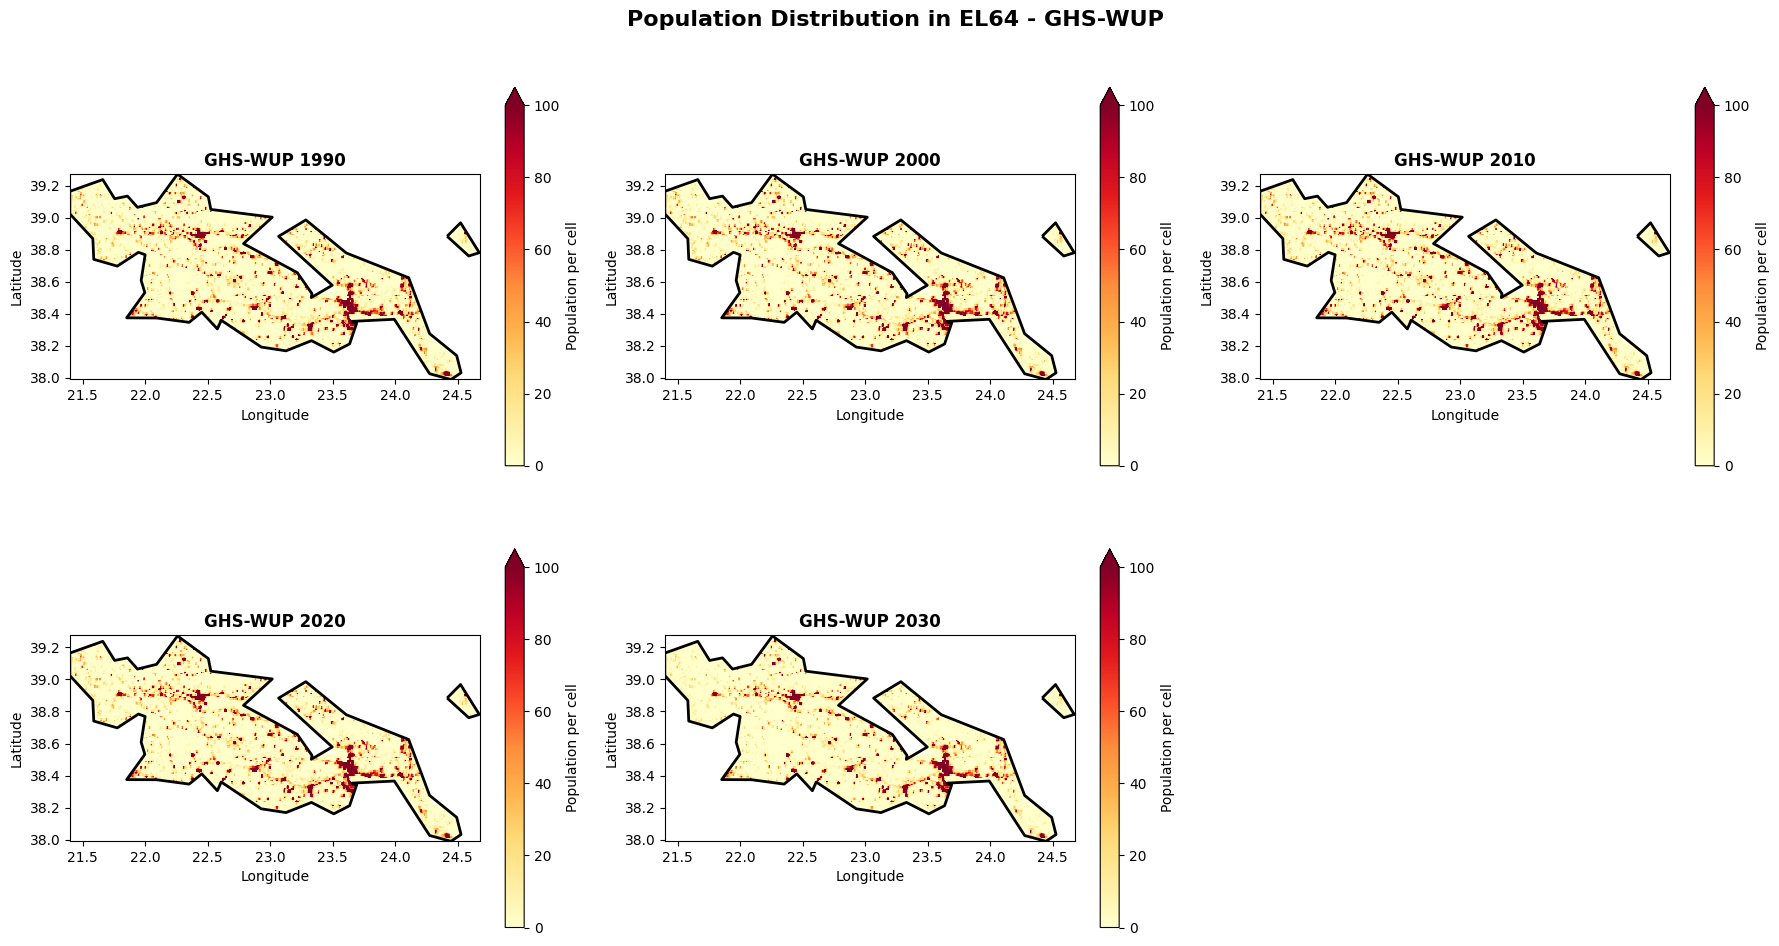

In [49]:
# Plot GHS-WUP for selected years
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, year in enumerate(selected_years_pop):
    if year in wup_data_dict:
        # Create mask for this specific year's coordinates
        mask_raw = admin_mask.mask(wup_data_dict[year].x, wup_data_dict[year].y)
        wup_mask = xr.DataArray(
            (~np.isnan(mask_raw.values)).astype(float),
            coords={'y': wup_data_dict[year].y, 'x': wup_data_dict[year].x},
            dims=['y', 'x']
        )
        
        masked_wup = wup_data_dict[year].where(wup_mask == 1)
        
        im = masked_wup.plot(
            ax=axes[idx],
            cmap='YlOrRd',
            add_colorbar=True,
            cbar_kwargs={'label': 'Population per cell', 'shrink': 0.8},
            vmin=0,
            vmax=100
        )
        
        axes[idx].set_title(f'GHS-WUP {year}', fontsize=12, fontweight='bold')
        axes[idx].set_xlabel('Longitude')
        axes[idx].set_ylabel('Latitude')
        sel_gdf.boundary.plot(ax=axes[idx], color='black', linewidth=2)

# Remove the last subplot if odd number
if len(selected_years_pop) < 6:
    fig.delaxes(axes[5])

plt.suptitle(f'Population Distribution in {admin_id} - GHS-WUP', fontsize=16, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

### Compare spatial patterns: Side-by-side

Let's compare GHS-POP and GHS-WUP for the same year to understand the differences.

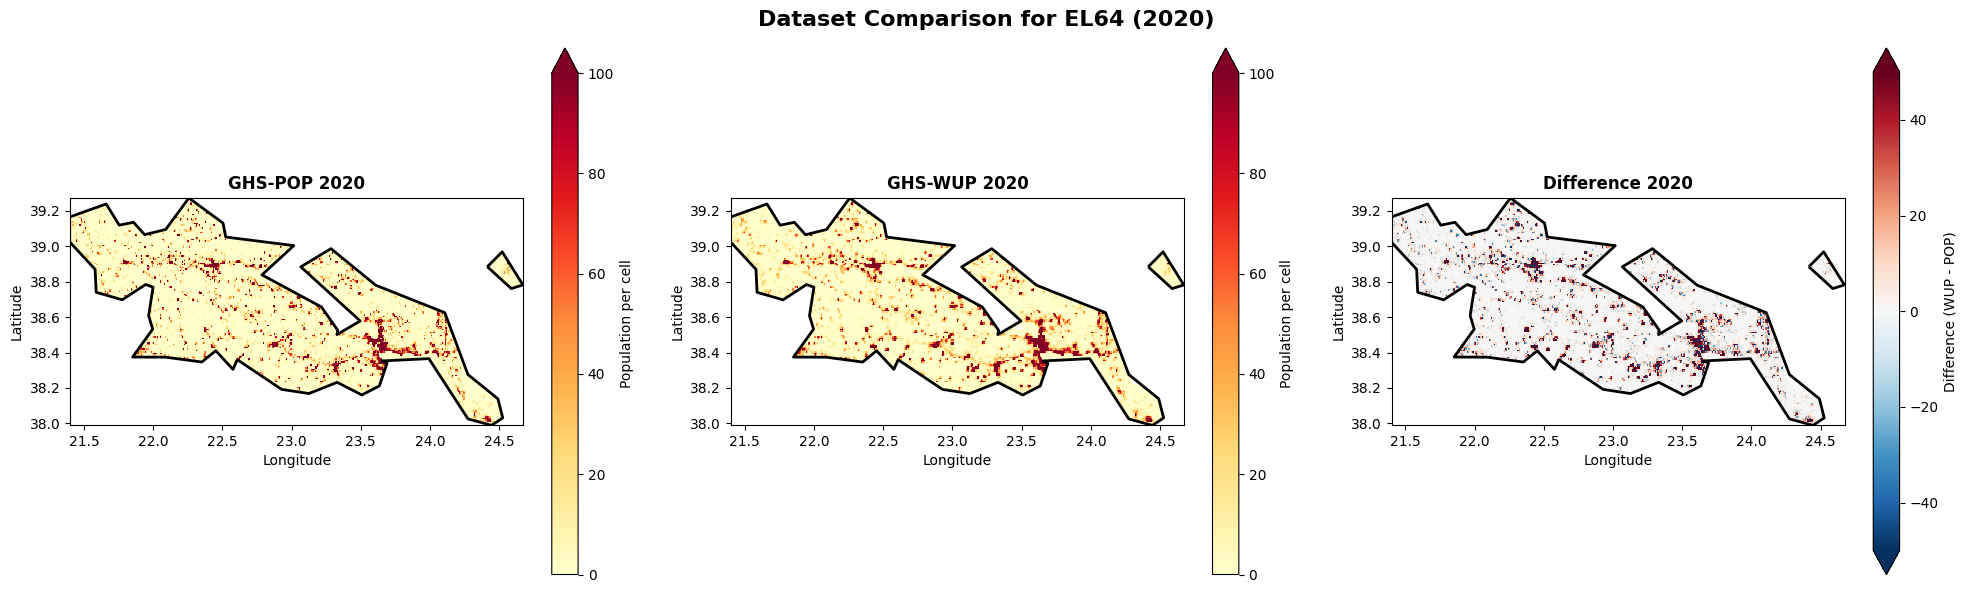

In [50]:
# Compare 2020 for both datasets
comparison_year = 2020

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# GHS-POP 2020
# Create mask for POP dataset
mask_pop_raw = admin_mask.mask(pop_data_dict[comparison_year].x, pop_data_dict[comparison_year].y)
masked_pop = pop_data_dict[comparison_year].where(~np.isnan(mask_pop_raw.values))

im1 = masked_pop.plot(
    ax=axes[0],
    cmap='YlOrRd',
    add_colorbar=True,
    cbar_kwargs={'label': 'Population per cell'},
    vmin=0,
    vmax=100
)
axes[0].set_title(f'GHS-POP {comparison_year}', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Longitude')
axes[0].set_ylabel('Latitude')
sel_gdf.boundary.plot(ax=axes[0], color='black', linewidth=2)

# GHS-WUP 2020
# Create mask for WUP dataset
mask_wup_raw = admin_mask.mask(wup_data_dict[comparison_year].x, wup_data_dict[comparison_year].y)
masked_wup = wup_data_dict[comparison_year].where(~np.isnan(mask_wup_raw.values))

im2 = masked_wup.plot(
    ax=axes[1],
    cmap='YlOrRd',
    add_colorbar=True,
    cbar_kwargs={'label': 'Population per cell'},
    vmin=0,
    vmax=100
)
axes[1].set_title(f'GHS-WUP {comparison_year}', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Longitude')
axes[1].set_ylabel('Latitude')
sel_gdf.boundary.plot(ax=axes[1], color='black', linewidth=2)

# Difference - ensure both are on same coordinates
# Interpolate WUP to POP coordinates if needed, or vice versa
try:
    # Try direct subtraction first
    difference = masked_wup - masked_pop
    # Check if result has any valid data
    if difference.isnull().all():
        # If all NaN, interpolate WUP to POP grid
        masked_wup_interp = masked_wup.interp_like(masked_pop)
        difference = masked_wup_interp - masked_pop
except:
    # If there's an error, try interpolation
    masked_wup_interp = masked_wup.interp_like(masked_pop)
    difference = masked_wup_interp - masked_pop

im3 = difference.plot(
    ax=axes[2],
    cmap='RdBu_r',
    add_colorbar=True,
    cbar_kwargs={'label': 'Difference (WUP - POP)'},
    center=0,
    vmin=-50,
    vmax=50

)
axes[2].set_title(f'Difference {comparison_year}', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Longitude')
axes[2].set_ylabel('Latitude')
sel_gdf.boundary.plot(ax=axes[2], color='black', linewidth=2)

plt.suptitle(f'Dataset Comparison for {admin_id} ({comparison_year})', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

### Future population change: GHS-WUP 2025 vs 2100

Let's explore how the GHS-WUP dataset projects population change by comparing present day (2025) with end-of-century (2100).

In [51]:
# Load 2025 and 2100 from GHS-WUP
future_years = [2025, 2100]
wup_future_dict = {}

for year in future_years:
    matching_files = [f for f in ghs_wup_files if f"E{year}" in f.name]
    if matching_files:
        tif_file = matching_files[0]
        ds = rxr.open_rasterio(tif_file)
        # Clip to region
        ds_clipped = ds.sel(x=slice(lon_min, lon_max), y=slice(lat_max, lat_min))
        ds_clipped = ds_clipped.where(ds_clipped >= 0)  # Remove fill values
        wup_future_dict[year] = ds_clipped.squeeze("band", drop=True)
        print(f"Loaded GHS-WUP {year}: shape {ds_clipped.shape}")

print(f"\nLoaded {len(wup_future_dict)} years for future comparison")

Loaded GHS-WUP 2025: shape (1, 154, 393)
Loaded GHS-WUP 2100: shape (1, 154, 393)

Loaded 2 years for future comparison


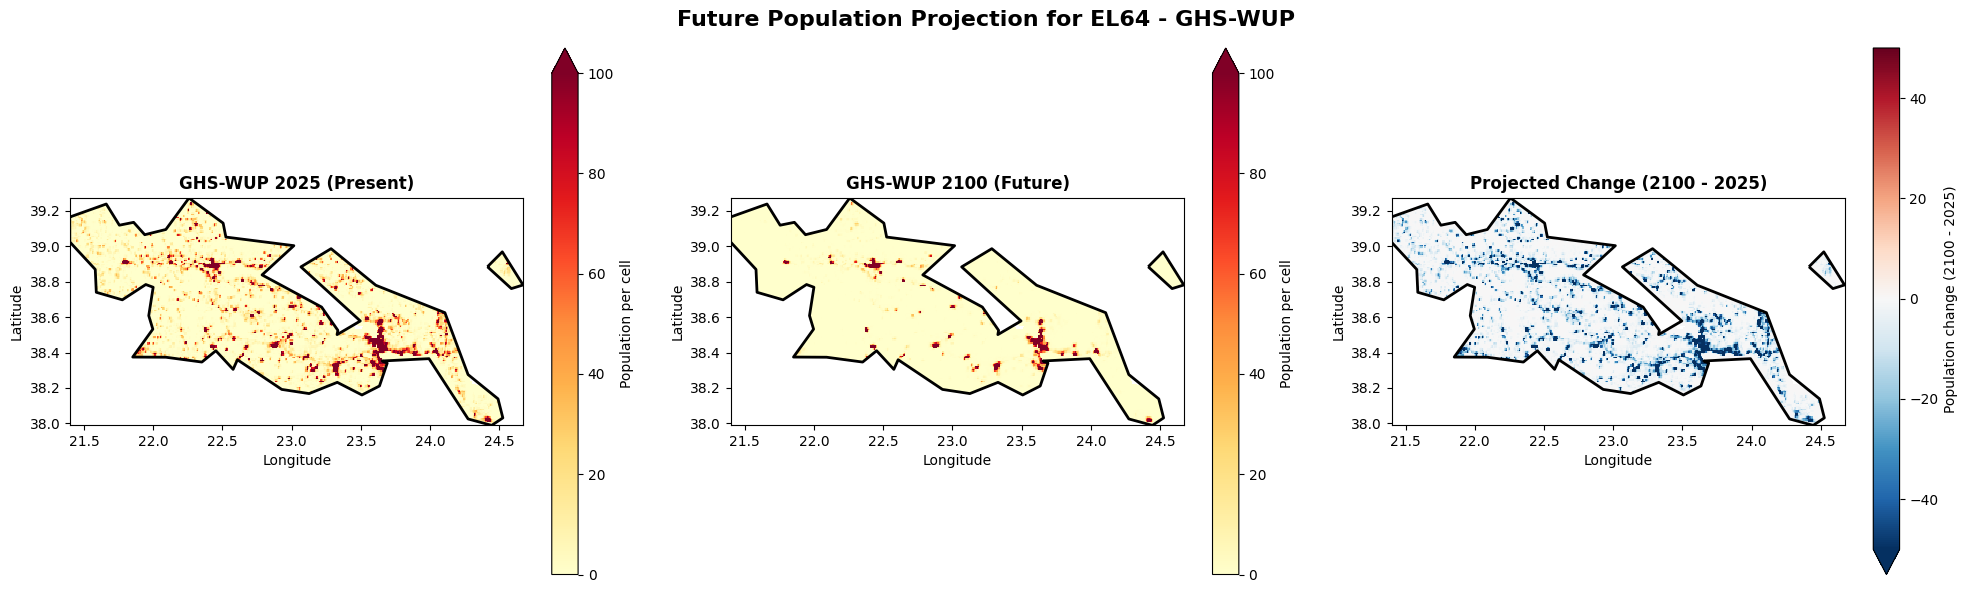


Population change summary (2025 → 2100):
  2025 total: 451,386
  2100 total: 184,935
  Absolute change: -266,451
  Percent change: -59.0%


In [52]:
# Compare 2025 vs 2100
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# 2025 (Present)
mask_2025 = admin_mask.mask(wup_future_dict[2025].x, wup_future_dict[2025].y)
masked_2025 = wup_future_dict[2025].where(~np.isnan(mask_2025.values))

im1 = masked_2025.plot(
    ax=axes[0],
    cmap='YlOrRd',
    add_colorbar=True,
    cbar_kwargs={'label': 'Population per cell'},
    vmin=0,
    vmax=100
)
axes[0].set_title('GHS-WUP 2025 (Present)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Longitude')
axes[0].set_ylabel('Latitude')
sel_gdf.boundary.plot(ax=axes[0], color='black', linewidth=2)

# 2100 (Future)
mask_2100 = admin_mask.mask(wup_future_dict[2100].x, wup_future_dict[2100].y)
masked_2100 = wup_future_dict[2100].where(~np.isnan(mask_2100.values))

im2 = masked_2100.plot(
    ax=axes[1],
    cmap='YlOrRd',
    add_colorbar=True,
    cbar_kwargs={'label': 'Population per cell'},
    vmin=0,
    vmax=100
)
axes[1].set_title('GHS-WUP 2100 (Future)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Longitude')
axes[1].set_ylabel('Latitude')
sel_gdf.boundary.plot(ax=axes[1], color='black', linewidth=2)

# Change (2100 - 2025)
# Interpolate if needed
try:
    future_change = masked_2100 - masked_2025
    if future_change.isnull().all():
        masked_2100_interp = masked_2100.interp_like(masked_2025)
        future_change = masked_2100_interp - masked_2025
except:
    masked_2100_interp = masked_2100.interp_like(masked_2025)
    future_change = masked_2100_interp - masked_2025

im3 = future_change.plot(
    ax=axes[2],
    cmap='RdBu_r',
    add_colorbar=True,
    cbar_kwargs={'label': 'Population change (2100 - 2025)'},
    center=0,
    vmin=-50,
    vmax=50
)
axes[2].set_title('Projected Change (2100 - 2025)', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Longitude')
axes[2].set_ylabel('Latitude')
sel_gdf.boundary.plot(ax=axes[2], color='black', linewidth=2)

plt.suptitle(f'Future Population Projection for {admin_id} - GHS-WUP', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# Print summary statistics
print(f"\nPopulation change summary (2025 → 2100):")
total_2025 = masked_2025.sum().values
total_2100 = masked_2100.sum().values if future_change.isnull().all() == False else masked_2100_interp.sum().values
change = total_2100 - total_2025
percent_change = (change / total_2025) * 100

print(f"  2025 total: {total_2025:,.0f}")
print(f"  2100 total: {total_2100:,.0f}")
print(f"  Absolute change: {change:+,.0f}")
print(f"  Percent change: {percent_change:+.1f}%")

## Key Takeaways

What have we learned about population exposure data?

1. **Temporal Coverage**: GHS-POP covers 1975-2030, while GHS-WUP extends to 2100
2. **Dataset Differences**: The two datasets show variations in population estimates, reflecting different methodologies
3. **Spatial Patterns**: Population is not uniformly distributed - urban centers show higher densities
4. **Temporal Trends**: Population changes over time can be quantified and visualized

**For risk assessment**: These differences matter when calculating drought exposure. Choose the appropriate dataset based on your analysis timeframe and the specific population aspect you're studying (total vs. urban).